# **European Drugs Development**

**A1 Team 10: Chamnan Suon**

## **Executive Summary**

This analysis examines patterns in European drug authorization outcomes, with a particular focus on understanding the regulatory characteristics and therapeutic themes associated with medicine refusal. Using a comprehensive dataset of drug submissions, the study combines exploratory data analysis, unsupervised learning, and unstructured text analysis to uncover both structural and thematic drivers of regulatory decisions.

After cleaning and preprocessing the data, regulatory pathway indicators were encoded as boolean features and used to explore similarities among medicines. Hierarchical clustering with Jaccard distance was applied to group medicines based on shared regulatory characteristics, with dendrograms providing interpretable insight into how these features co-occur. Cluster-level summaries reveal meaningful heterogeneity in refusal rates, suggesting that certain combinations of regulatory attributes—such as orphan designation or exceptional circumstances—are associated with elevated refusal risk. To validate robustness, K-modes clustering was also performed as an alternative method better suited for categorical data, producing broadly consistent cluster profiles while offering clearer modal interpretations of regulatory pathways.

In parallel, unstructured text analysis was conducted on therapeutic area descriptions for refused medicines. Text was transformed using TF-IDF vectorization with unigrams and bigrams, enabling clustering of refused drugs based on clinical themes rather than structured attributes alone. This approach highlights recurring therapeutic contexts among refusals, complementing the structured clustering results and reinforcing the role of clinical uncertainty in regulatory outcomes.

Overall, the findings indicate that authorization refusal is relatively rare but systematically associated with specific regulatory and therapeutic characteristics. Refusals appear less driven by company-level behavior and more by project-level risk, particularly in areas involving novel, rare, or high-uncertainty treatments. By integrating structured and unstructured methods, this analysis provides a nuanced, data-driven view of regulatory decision-making and offers actionable insights for stakeholders seeking to anticipate and mitigate authorization risk.

## **Data Dictionary**

# `drugs_dataset.csv`

|Column  |Class      |Description          |
|:-------|:----------|:--------------------|
|category|character | human or veterinary|
|medicine_name | character | brand name of the medicine|
|therapeutic_area | character | semicolon-separated list of therapeutic areas|
|common_name | character | international non-proprietary name (INN) or common name|
|active_substance | character | common name of the active chemical in the drug|
|product_number | character | EMEA/H/C/ (human) or EMEA/V/C/ (veterinary) number for the drug|
|patient_safety | logical | has patient safety notices|
|authorisation_status | character | whether the drug was authorised, withdrawn, or refused (or does not have a reported status)|
|atc_code | character | anatomical therapeutic chemical code|
|additional_monitoring | logical | when true, the medicine is under additional monitoring, meaning that it is monitored even more intensively than other medicines|
|generic | logical | whether the drug is a generic medicine, which is developed to be the same as a medicine that has already been authorised, called the reference medicine. A generic medicine contains the same active substance(s) as the reference medicine, and is used at the same dose(s) to treat the same disease(s)|
|biosimilar | logical | whether the drug is a biosimilar medicine, which is a biological medicine highly similar to another already approved biological medicine called the reference medicine.|
|conditional_approval | logical | whether the medicine received a conditional marketing authorisation. This was granted in the interest of public health because the medicine addresses an unmet medical need and the benefit of immediate availability outweighs the risk from less comprehensive data than normally required.|
|exceptional_circumstances | logical | whether the medicine was authorised under exceptional circumstances, because the applicant was unable to provide comprehensive data on the efficacy and safety of the medicine under normal conditions of use. This can happen because the condition to be treated is rare or because collection of full information is not possible or is unethical.|
|accelerated_assessment | logical | whether the medicine had an accelerated assessment. This means that it is a medicine of major interest for public health, so its timeframe for review was 150 evaluation days rather than 210.|
|orphan_medicine | logical | whether the medicine was designated an orphan medicine. This means that it was developed for use against a rare, life-threatening or chronically debilitating condition or, for economic reasons, it would be unlikely to have been developed without incentives.|
|marketing_authorisation_date | date | date on which the drug was authorised|
|date_of_refusal_of_marketing_authorisation | date | date on which the drug was refused|
|marketing_authorisation_holder_company_name | character | name of the company that is authorised to market the drug|
|pharmacotherapeutic_group | character | the target of the drug|
|date_of_opinion | date | date on which the opinion was made|
|decision_date | date | date on which the latest decision was made|
|revision_number | integer | integer revision number|
|condition_indication | character | language describing the specific uses of the drug|
|species | character | for veterinary medicines, the target species; might benefit from further cleaning|
|first_published | datetime | datetime when the information was first published|
|revision_date | datetime | datetime of the most recent revision|
|url | character | url for details about the drug and submission|

## **Load Dataset**

In [124]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [125]:
# Import pandas and numpy for DataFrame and operations
import pandas as pd
import numpy as np

In [126]:
# Load dataset from GitHub relative path
path = "https://raw.githubusercontent.com/SChamnan/ba820-unsupervised-ml-team10-project/refs/heads/main/european-drugs-development/drugs-dataset.csv"
drugs_df = pd.read_csv(path)

# View the first 5 rows of drugs dataset
drugs_df.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


## **Data Cleaning and Preprocessing**

High level overview of the dataset and data type. Also perform count of missing values in each column to have a better understanding of the overall dataset structure.

Upon observing data, `date_of_refusal_of_marketing_authorization` column has over 96% of missing values. This does not mean that data is missing but rather not available for medicines that were successfully authorized in the first attempt. Similarly, `species` column has over 85% of missing values. This is because instead of labeling value as 'human' or 'homo sapien', no value is given. This can be verified with `category` column which has two values; `human` and `veterinary`, where `human` correspond to nan.

In [127]:
# Check out number of rows and columns in drugs dataset as well as each column datatype
print("Number of rows and columns of the dataset, respectively,:", drugs_df.shape)
print("Datatype of columns in drugs dataset", drugs_df.dtypes)

Number of rows and columns of the dataset, respectively,: (1988, 28)
Datatype of columns in drugs dataset category                                        object
medicine_name                                   object
therapeutic_area                                object
common_name                                     object
active_substance                                object
product_number                                   int64
patient_safety                                    bool
authorisation_status                            object
atc_code                                        object
additional_monitoring                             bool
generic                                           bool
biosimilar                                        bool
conditional_approval                              bool
exceptional_circumstances                         bool
accelerated_assessment                            bool
orphan_medicine                                   bool
marketing_auth

In [128]:
# Check out total missing values in each column
missing_values = drugs_df.isnull().sum()
missing_percentage = ((drugs_df.isnull().sum() / len(drugs_df)) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_info.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
date_of_refusal_of_marketing_authorisation,1913,96.23
species,1709,85.97
date_of_opinion,779,39.19
therapeutic_area,285,14.34
revision_number,96,4.83
marketing_authorisation_date,60,3.02
decision_date,45,2.26
pharmacotherapeutic_group,34,1.71
revision_date,29,1.46
atc_code,28,1.41


In [129]:
# Get the count of all unique values, including NaN, for 'authorisation_status'
unique_auth_status_with_nan = drugs_df['authorisation_status'].value_counts(dropna=False)
print("Unique values and their counts (including NaN) in 'authorisation_status' column:")
print(unique_auth_status_with_nan)

# You can apply the same to other columns as needed, for example 'category'
unique_category_with_nan = drugs_df['category'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'category' column:")
print(unique_category_with_nan)

Unique values and their counts (including NaN) in 'authorisation_status' column:
authorisation_status
authorised    1573
withdrawn      357
refused         57
NaN              1
Name: count, dtype: int64

Unique values and their counts (including NaN) in 'category' column:
category
human         1706
veterinary     282
Name: count, dtype: int64


### **Categorization of the Columns**

In [130]:
# Categorize columns type
# Category cols
cat_cols = ["category",
            "medicine_name",
            "common_name",
            "active_substance",
            "authorisation_status",
            "atc_code",
            "marketing_authorisation_holder_company_name"]

#text cols
text_cols = ["condition_indication"]

# id cols
id_cols = ["url", "product_number"]

# list text cols
list_text_cols = ["therapeutic_area",
                  "pharmacotherapeutic_group",
                  "species"]

# Numeric cols
numeric_cols = ["revision_number"]

# Boolean cols
boolean_cols = ["patient_safety",
                "additional_monitoring",
                "generic",
                "biosimilar",
                "conditional_approval",
                "exceptional_circumstances",
                "accelerated_assessment",
                "orphan_medicine",
                ]

# Datetime cols
datetime_cols = ["marketing_authorisation_date",
             "date_of_refusal_of_marketing_authorisation",
             "date_of_opinion",
             "decision_date",
             "revision_date",
             "first_published"]

### **Cleaning**

User-defined functions are created to handle data cleaning in drugs dataset. These user-defined funtions were created in M1 phase and now it being used again in M2 phase.

- **clean_string_series(s)**
This function cleans a text column in a consistent way. It converts the column to a string type, replaces multiple spaces with a single space, and removes extra spaces at the beginning and end of each value. This helps avoid errors caused by inconsistent spacing.

- **clean_list_text_column(s)**
This function cleans columns that contain lists stored as text using semicolons (for example: "A;B"). It first applies basic text cleaning (spacing and trimming). Then it standardizes the semicolon format so items are separated as "; " (semicolon + one space). This makes splitting the list later more reliable.

- **clean_species_column(s)**
This function is a specialized cleaner for the species column. It applies the semicolon list cleaning, removes extra text written inside parentheses (for example: "Pigs (for fattening)" becomes "Pigs"), and standardizes semicolon spacing again. This produces a cleaner and more consistent species field for later grouping and analysis.

In [131]:
def clean_string_series(s):
    """
    Standard string cleanup:
    - converts to pandas 'string' dtype
    - normalizes whitespace (multiple spaces -> one)
    - trims leading/trailing whitespace
    """
    s = s.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def clean_list_text_column(s):
    """
    Cleanup for semicolon-separated list fields like:
    therapeutic_area, pharmacotherapeutic_group, species.
    - normalizes whitespace
    - standardizes delimiter spacing: "A;B" -> "A; B"
    """
    s = clean_string_series(s)
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

def clean_species_column(s):
    """
    Extra cleanup for species:
    - removes parenthetical qualifiers: 'Pigs (for fattening)' -> 'Pigs'
    - standardizes semicolon spacing: 'Dogs;Cats' -> 'Dogs; Cats'
    """
    s = clean_list_text_column(s)
    s = s.str.replace(r"\s*\(.*?\)\s*", "", regex=True).str.strip()
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

Apply user-defined functions into cleaning drugs dataset.

In [132]:
drugs_df = drugs_df.copy()

# Clean category/text/id columns (trim + normalize spacing)
for c in (cat_cols + text_cols + id_cols):
    if c in drugs_df.columns:
        drugs_df[c] = clean_string_series(drugs_df[c])

# Clean list-text columns
for c in list_text_cols:
    if c in drugs_df.columns:
        if c == "species":
            drugs_df[c] = clean_species_column(drugs_df[c])
        else:
            drugs_df[c] = clean_list_text_column(drugs_df[c])

# Standardize small categorical fields
if "category" in drugs_df.columns:
    drugs_df["category"] = drugs_df["category"].astype("string").str.lower().str.strip()

if "authorisation_status" in drugs_df.columns:
    drugs_df["authorisation_status"] = drugs_df["authorisation_status"].astype("string").str.lower().str.strip()

if "atc_code" in drugs_df.columns:
    drugs_df["atc_code"] = drugs_df["atc_code"].astype("string").str.upper().str.strip()

# Cast numeric group
for c in numeric_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_numeric(drugs_df[c], errors="coerce").astype("Int64")


# Cast datetimes group
for c in datetime_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_datetime(drugs_df[c], errors="coerce")


# Quick checks
print("Category counts:\n", drugs_df["category"].value_counts(dropna=False), "\n")
print("Status counts:\n", drugs_df["authorisation_status"].value_counts(dropna=False), "\n")
if "species" in drugs_df.columns:
    print("Top species values:\n", drugs_df["species"].value_counts(dropna=False).head())


Category counts:
 category
human         1706
veterinary     282
Name: count, dtype: Int64 

Status counts:
 authorisation_status
authorised    1573
withdrawn      357
refused         57
<NA>             1
Name: count, dtype: Int64 

Top species values:
 species
<NA>          1709
Dogs            71
Pigs            36
Cats            28
Dogs; Cats      18
Name: count, dtype: Int64


In [158]:
# Check out cleaned dataset
drugs_df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,revision_number,condition_indication,species,first_published,revision_date,url,cluster_labels,is_refused,cluster_kmodes,cluster
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,34,Hodgkin lymphomaAdcetris is indicated for adul...,<NA>,2018-07-25 13:58:00+00:00,2023-03-13 11:52:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,3,False,2,3
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,4,Treatment of adult and paediatric patients wit...,<NA>,2018-07-26 14:20:00+00:00,2023-03-10 17:29:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,2,False,3,3
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,2,Ebvallo is indicated as monotherapy for treatm...,<NA>,2022-10-12 16:13:00+00:00,2023-03-10 13:40:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,3,False,1,3
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,3,Ronapreve is indicated for:Treatment of COVID-...,<NA>,2021-11-12 16:30:00+00:00,2023-03-10 12:29:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,3,False,1,3
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,30,Plaque psoriasisCosentyx is indicated for the ...,<NA>,2018-06-07 11:59:00+00:00,2023-03-09 18:53:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,1,False,2,3


## **Exploratory Data Analysis**

After data cleaning and preprocessing, the dataset is ready for further analysis and mainly around the domaint question of ***Which medicines are more likely to be refused to get authorization into the market? What features may influence this decision?***

In [135]:
# Import library for plotting
import matplotlib.pyplot as plt

Figure1 shows medicines that were refused for market authorization over time with 2013 and 2019 have the most refusal. The number remains relatively low. Additionally, figure2 presents the records of medicines that were initially refused and later approved for authorization. This indicate that initial refusal does not always mean final, allowing companies to re-evaluate and improve their development process.

The logic behind figure2 is fitlering in `authorisation_status` = 'authorised' and filtering out `date_of_refusal_of_marketing_authorisation` = NA.



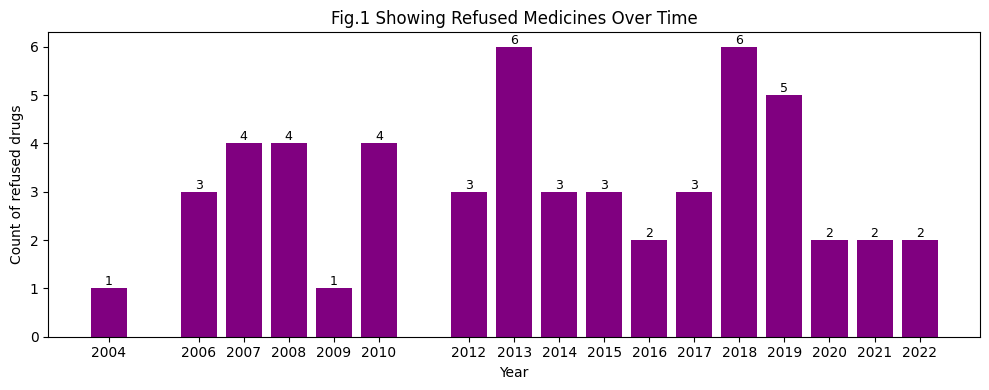

In [136]:
# Graph showing count of refused medicines over time
# Refused medicine is when authorisation = refused
refused_df = drugs_df[drugs_df["authorisation_status"]=="refused"].copy()

refused_df["refused_year"] = refused_df["date_of_refusal_of_marketing_authorisation"].dt.year

refused_count = refused_df["refused_year"].value_counts().sort_index()

plt.figure(figsize=(10,4))
bars = plt.bar(refused_count.index.astype(int), refused_count.values, color='purple')

# Add number on each bar
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
  )

plt.title("Fig.1 Showing Refused Medicines Over Time")
plt.xlabel("Year")
plt.ylabel("Count of refused drugs")
plt.xticks(refused_count.index.astype(int))
plt.tight_layout()

plt.show()

/tmp/ipython-input-107820963.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refused_df2["refused_year"] = refused_df2["date_of_refusal_of_marketing_authorisation"].dt.year


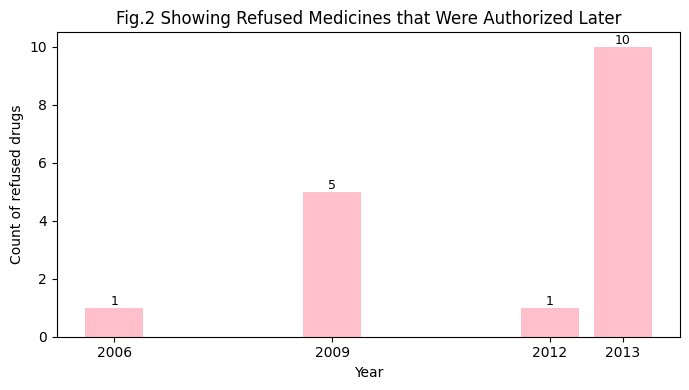

In [137]:
# Graph showing count of refused medicines over time
# Refused medicine is when authorisation = refused
refused_df2 = drugs_df[
    drugs_df["date_of_refusal_of_marketing_authorisation"].notna()&
    (drugs_df["authorisation_status"].str.lower()=="authorised")
]

refused_df2["refused_year"] = refused_df2["date_of_refusal_of_marketing_authorisation"].dt.year

refused_count = refused_df2["refused_year"].value_counts().sort_index()

plt.figure(figsize=(7,4))
bars = plt.bar(refused_count.index.astype(int), refused_count.values, color='pink')

# Add number on each bar
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
  )

plt.title("Fig.2 Showing Refused Medicines that Were Authorized Later")
plt.xlabel("Year")
plt.ylabel("Count of refused drugs")
plt.xticks(refused_count.index.astype(int))
plt.tight_layout()

plt.show()

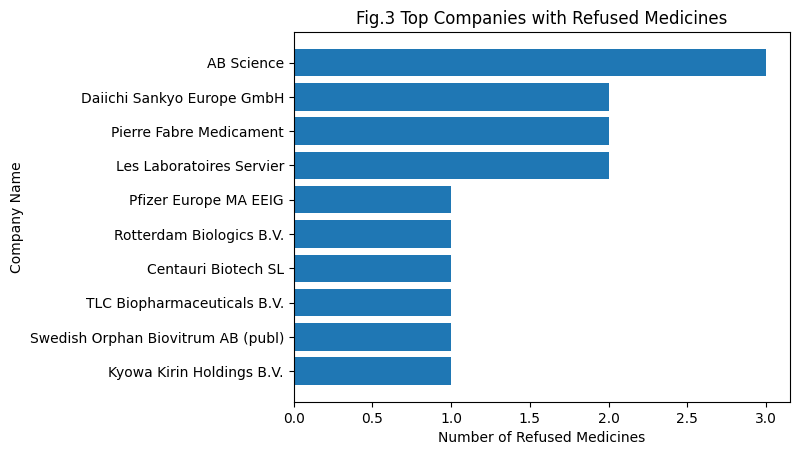

In [138]:
# Graph of company name with drugs refusal
# Column names
STATUS_COL = "authorisation_status"
COMPANY_COL = "marketing_authorisation_holder_company_name"

# Filter refused medicines (robust to case issues)
refused_df = drugs_df[
    drugs_df[STATUS_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("refused")
].copy()

# Count refused medicines by company (top 10)
company_refused_count = (
    refused_df[COMPANY_COL]
    .value_counts()
    .head(10)
)

# Plot horizontal bar chart
plt.figure()

plt.barh(company_refused_count.index, company_refused_count.values)
plt.xlabel("Number of Refused Medicines")
plt.ylabel("Company Name")
plt.title("Fig.3 Top Companies with Refused Medicines")

# Show highest count at the top
plt.gca().invert_yaxis()

plt.show()

## **Analysis and Experiments**

### **Unsupervised Methods**

#### **Association Rules Mining**

Result shows a weak association between whether a medicine is for humans or vet use and its authorization outcome.

Result below shows, although still weak, orphan_medicine and additional_monitoring have the strongest association among other booleans.

This means that being an orphan medicine or under additional monitoring slightly changes the likelyhood of authorization status.

Note that it is directionally interesting but not predictive.

In [139]:
# Discover co-occurance pattern between regulatory pathways and medicine refusal
# setup association rules mining
boolean_cols = ["patient_safety",
                "additional_monitoring",
                "generic",
                "biosimilar",
                "conditional_approval",
                "exceptional_circumstances",
                "accelerated_assessment",
                "orphan_medicine",
                ]
# Create a filterd datafram including boolean features and authorisation_status
df_arm = drugs_df[boolean_cols+["authorisation_status"]].copy()

# Create boolean indicator for authorisation_status
df_arm["refused"] = (df_arm["authorisation_status"].astype(str).str.lower().str.contains("refus"))

# Convert each medicine into a transaction like basket of items in class
txn = []

for _, row in df_arm.iterrows():
  items=[]
  for col in boolean_cols:
    if row[col] is True:
      items.append(col)
  if row["refused"]:
    items.append("REFUSED")
  txn.append(items)

# Use one-hot encode to each transaction
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

te = TransactionEncoder()
te_array = te.fit(txn).transform(txn)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# Find frequent itemsets
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.0001,
    use_colnames=True
  )

# Create rules on the itemsets
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.002
)

# filter to include only rules with refusal in outcome
refusal_rules = rules[
    rules["consequents"].apply(lambda x: "REFUSED" in x)
].sort_values(by="lift", ascending=False)


refusal_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
41,(orphan_medicine),"(REFUSED, additional_monitoring)",0.000503,0.006173,12.271605
7,(orphan_medicine),(REFUSED),0.007545,0.092593,3.229370
2,(biosimilar),(REFUSED),0.001006,0.021739,0.758200
38,"(additional_monitoring, orphan_medicine)",(REFUSED),0.000503,0.009901,0.345319
40,(additional_monitoring),"(REFUSED, orphan_medicine)",0.000503,0.002584,0.342463
4,(generic),(REFUSED),0.000503,0.003175,0.110721
1,(additional_monitoring),(REFUSED),0.000503,0.002584,0.090122


#### **Hierarchical Clustering**



##### **Dendrogram**

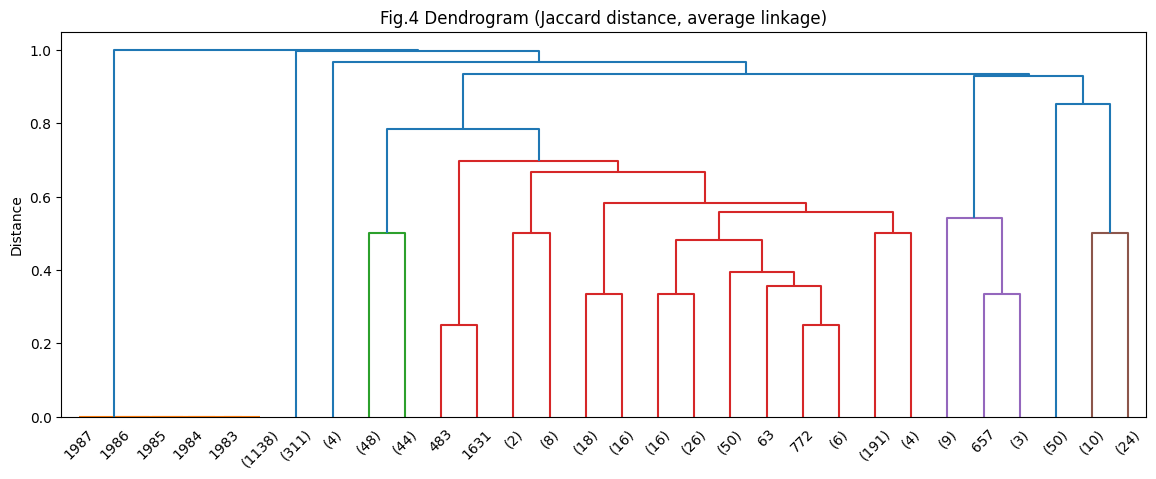

In [140]:
# hierarchical clustering

# import needed libraries
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# encode booleans from True/False to 1/0
X = drugs_df[boolean_cols].astype(int)

# compute distance with pdist() and condensed distance vector
distance = pdist(X, metric="jaccard")

# hierarchical clustering on distances
Z = linkage(distance, method="average")

# Plot
plt.figure(figsize=(14,5))
dendrogram(Z,
           truncate_mode="lastp", # show only the last p merged clusters to avoid error RecursionError: maximum recursion depth exceeded
           p=30,
           show_leaf_counts=True,
           no_labels=False)
plt.title("Fig.4 Dendrogram (Jaccard distance, average linkage)")
plt.ylabel("Distance")
plt.show()

##### **Visualize Cluster Profiles on Regulatory Boolean Features**

In [141]:
n_clusters = 3

drugs_df["cluster_labels"] = fcluster(Z, n_clusters, criterion="maxclust").astype(str)

drugs_df

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,cluster_labels
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Antineoplastic agents,2012-07-19,2022-11-17,34,Hodgkin lymphomaAdcetris is indicated for adul...,<NA>,2018-07-25 13:58:00+00:00,2023-03-13 11:52:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,3
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4,Treatment of adult and paediatric patients wit...,<NA>,2018-07-26 14:20:00+00:00,2023-03-10 17:29:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,2
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,<NA>,2022-10-13,2023-03-09,2,Ebvallo is indicated as monotherapy for treatm...,<NA>,2022-10-12 16:13:00+00:00,2023-03-10 13:40:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,3
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3,Ronapreve is indicated for:Treatment of COVID-...,<NA>,2021-11-12 16:30:00+00:00,2023-03-10 12:29:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,3
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Immunosuppressants,2014-11-20,2023-01-26,30,Plaque psoriasisCosentyx is indicated for the ...,<NA>,2018-06-07 11:59:00+00:00,2023-03-09 18:53:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,human,Liprolog,Diabetes Mellitus,insulin lispro,insulin lispro,143,False,withdrawn,A10AB04,False,...,"Insulins and analogues for injection, fast-act...",NaT,2001-02-19,0,For the treatment of patients with diabetes me...,<NA>,2001-02-19 01:00:00+00:00,2001-08-01 00:00:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,1
1984,human,EchoGen,Echocardiography,dodecafluoropentane,dodecafluoropentane,149,False,withdrawn,V08DA,False,...,Contrast media,NaT,2001-01-22,0,EchoGen is a transpulmonary echocardiographic ...,<NA>,2001-01-22 01:00:00+00:00,2001-05-22 00:00:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,1
1985,human,Ecokinase,Myocardial Infarction,reteplase,reteplase,106,False,withdrawn,B01AD07,False,...,Antithrombotic agents,NaT,1999-07-30,0,Thrombolytic therapy of acute myocardial infar...,<NA>,1999-07-30 00:00:00+00:00,2000-12-12 01:00:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,1
1986,human,Primavax,Hepatitis B; Tetanus; Immunization; Diphtheria,"diphtheria, tetanus and hepatitis b (rdna) vac...","diphtheria toxoid, hepatitis b, recombinant su...",156,False,withdrawn,J07CA,False,...,"Vaccines,",NaT,2000-07-27,0,This vaccine is indicated for active immunizat...,<NA>,2000-07-27 00:00:00+00:00,2000-12-04 01:00:00+00:00,https://www.ema.europa.eu/en/medicines/human/E...,1


In [142]:
drugs_df["cluster_labels"].value_counts()

,count
cluster_labels,
1,1143
3,534
2,311


In [143]:
cluster_modes = pd.DataFrame(
    km.cluster_centroids_,
    columns=boolean_cols
)

cluster_modes.index = range(1, k + 1)
cluster_modes

,patient_safety,additional_monitoring,generic,biosimilar,conditional_approval,exceptional_circumstances,accelerated_assessment,orphan_medicine
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0


##### **Refusal Rate in Each Cluster**

Refusal rates differ substantially across clusters. Generic medicines shows a near-zero refusal rate, while both standard medicines and those subject to complex regulatory pathways show higher refusal rates. This suggests that regulatory complexity is associated with elevated uncertainty in authorization outcomes.

In [144]:
# Create refusal flag
drugs_df["is_refused"] = (
    drugs_df["authorisation_status"]
    .astype(str)
    .str.lower()
    .str.contains("refus")
)

# Calcualte refusal rate for cluster
cluster_refusal = (
    drugs_df
    .groupby("cluster_labels")
    .agg(
        total_medicines=("cluster_labels", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
)

cluster_refusal

,cluster_labels,total_medicines,refused_medicines,refusal_rate
0,1,1143,39,0.034121
1,2,311,1,0.003215
2,3,534,17,0.031835


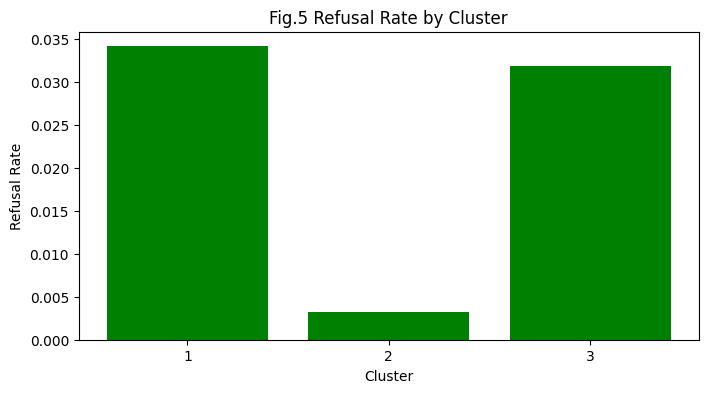

In [145]:
# Visualizing refusal rate in each cluster
plt.figure(figsize=(8,4))
plt.bar(
    cluster_refusal.index + 1,
    cluster_refusal["refusal_rate"],
    color = "Green"
)

plt.xticks((cluster_refusal.index+1).astype(int))

plt.xlabel("Cluster")
plt.ylabel("Refusal Rate")
plt.title("Fig.5 Refusal Rate by Cluster")
plt.show()

#### **K-Modes Clustering**

In [146]:
pip install kmodes

In [147]:
# import kmodes
from kmodes.kmodes import KModes

# Boolean features
X = drugs_df[boolean_cols].astype(int)

# num of clustering
k=3

km = KModes(
    n_clusters=k,
    init="Huang",
    n_init=5,
    verbose=0,
    random_state=42
)

drugs_df["cluster_kmodes"] = km.fit_predict(X)

In [148]:
cluster_modes = pd.DataFrame(
    km.cluster_centroids_,
    columns=boolean_cols
)

cluster_modes.index = range(1, k + 1)
cluster_modes


,patient_safety,additional_monitoring,generic,biosimilar,conditional_approval,exceptional_circumstances,accelerated_assessment,orphan_medicine
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0


##### **Visualize Cluster Profiles on Regulatory Boolean Features**

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assign kmodes clusters (start at 1)
drugs_df["cluster_kmodes"] = km.fit_predict(X) + 1

# Create refusal flag
drugs_df["is_refused"] = (
    drugs_df["authorisation_status"]
    .astype(str)
    .str.lower()
    .str.contains("refus")
)

# Aggregate cluster-level statistics
cluster_outcome_km = (
    drugs_df
    .groupby("cluster_kmodes")
    .agg(
        total_medicines=("cluster_kmodes", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
)

cluster_outcome_km


,cluster_kmodes,total_medicines,refused_medicines,refusal_rate
0,1,387,1,0.002584
1,2,1290,55,0.042636
2,3,311,1,0.003215


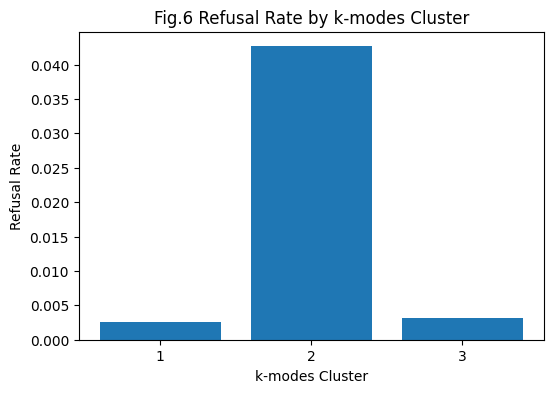

In [150]:
# Visualize refusal rate
plt.figure(figsize=(6,4))
plt.bar(
    cluster_outcome_km.index+1,
    cluster_outcome_km["refusal_rate"]
)

plt.xticks((cluster_outcome_km.index+1).astype(int))

plt.xlabel("k-modes Cluster")
plt.ylabel("Refusal Rate")
plt.title("Fig.6 Refusal Rate by k-modes Cluster")
plt.show()

#### **Comparing Between Hierarchical and K-Modes Clusterings**

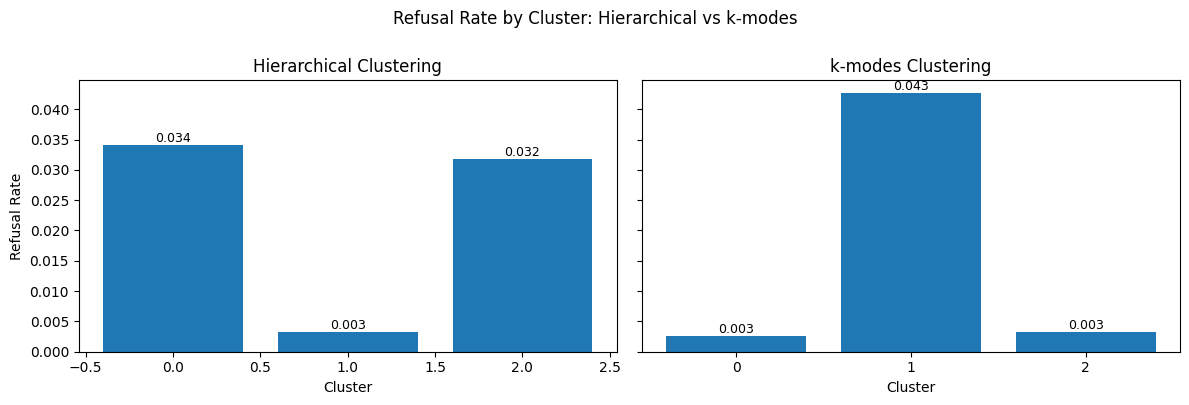

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Hierarchical clustering
plt.xticks(cluster_refusal.index.astype(int))

axes[0].bar(
    cluster_refusal.index,
    cluster_refusal["refusal_rate"]
)
axes[0].set_title("Hierarchical Clustering")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Refusal Rate")

# k-modes clustering
plt.xticks(cluster_outcome_km.index.astype(int))

axes[1].bar(
    cluster_outcome_km.index,
    cluster_outcome_km["refusal_rate"]
)
axes[1].set_title("k-modes Clustering")
axes[1].set_xlabel("Cluster")

plt.suptitle("Refusal Rate by Cluster: Hierarchical vs k-modes", y=1)
plt.tight_layout()

for ax, df in zip(axes, [cluster_refusal, cluster_outcome_km]):
    for x, y in zip(df.index, df["refusal_rate"]):
        ax.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

plt.show()

### **Unstructured Methods**

#### **K-Means**

Perform k-means clustering on `therapeutic_area` to find pattern in drugs refusal based on keywords in each clustering.

In [152]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Keep rows with therapeutic text
drugs_df = drugs_df.dropna(subset=["therapeutic_area"]).copy()

# Identify refused drugs
drugs_df["is_refused"] = drugs_df["authorisation_status"].str.lower().str.contains("refus")

refused_df = drugs_df[drugs_df["is_refused"]].copy()

In [153]:
# Convert text in therapeutic_area into a numeric matrix to analyze patterns
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_refused = vectorizer.fit_transform(refused_df["therapeutic_area"])

In [154]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")

refused_df["cluster"] = kmeans.fit_predict(X_refused)

In [155]:
# list items in each cluster
terms = np.array(vectorizer.get_feature_names_out())

for c in range(k):
    top_idx = kmeans.cluster_centers_[c].argsort()[-10:][::-1]
    print(f"\nCluster {c+1} – top therapeutic terms:")
    print(", ".join(terms[top_idx]))


Cluster 1 – top therapeutic terms:
neoplasms, breast, breast neoplasms, sclerosis, syndrome, tissue, myeloid acute, myeloid, major, lymphoma non

Cluster 2 – top therapeutic terms:
disease, tissue, sclerosis, non hodgkin, non, syndrome, myeloid acute, myeloid, major, lymphoma non

Cluster 3 – top therapeutic terms:
diseases, cell, fibromyalgia, disorders, syndrome, sclerosis, disease, tissue, lymphoma, non


In [156]:
# Apply the same vectorizer + model to all drugs
X_all = vectorizer.transform(drugs_df["therapeutic_area"])
drugs_df["cluster"] = kmeans.predict(X_all) +1

cluster_refusal = (
    drugs_df.groupby("cluster")
    .agg(
        total_medicines=("authorisation_status", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
    .sort_values("cluster", ascending=True)
)

cluster_refusal

,cluster,total_medicines,refused_medicines,refusal_rate
0,1,127,5,0.03937
1,2,106,2,0.018868
2,3,1470,46,0.031293


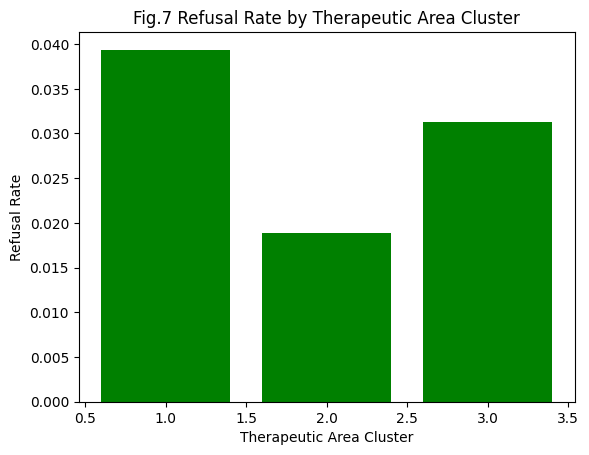

In [157]:
plt.figure()
plt.bar(cluster_refusal["cluster"], cluster_refusal["refusal_rate"], color='green')
plt.xlabel("Therapeutic Area Cluster")
plt.ylabel("Refusal Rate")
plt.title("Fig.7 Refusal Rate by Therapeutic Area Cluster")
plt.show()